In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [2]:
#load the data
wine_data=pd.read_csv('/content/wine_data.csv')
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
#checking whether there are any null data present
wine_data.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [4]:
duplicates=wine_data.duplicated().sum()
print(f"duplicates: {duplicates}")

duplicates: 240


In [5]:
#removing the 240 duplicated data from the original data
data=wine_data.drop_duplicates()
duplicates_new=data.duplicated().sum()
print(f"duplicates in updated data:{duplicates_new}")

duplicates in updated data:0


# **QUESTION 1**

### What is the most frequently occurring wine quality? What is the highest number in and the lowest number in the quantity column?

most frequent quality: 5
highest number: 577
lowest number: 10
counts:


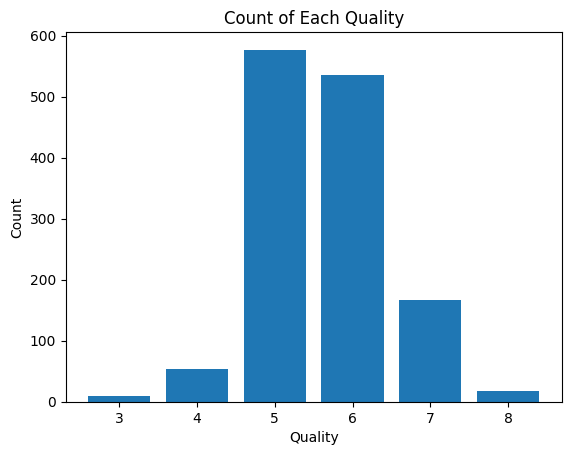

In [6]:
#most frequent quality--> mode of the values in the quality column
most_frequent_quality=data['quality'].mode()[0]
print(f"most frequent quality: {most_frequent_quality}")

#highest,lowest represent the highest and lowest count of the quality
highest=data['quality'].value_counts().max()
lowest=data['quality'].value_counts().min()
print(f"highest number: {highest}")
print(f"lowest number: {lowest}")
print(f"counts:")
count_data=data['quality'].value_counts()

#bar graph gives the visualizing effect to understand the frequency of quality rate in the data
plt.bar(count_data.index, count_data.values)
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Count of Each Quality')
plt.show()

# **QUESTION 2**

### How is `fixed acidity` correlated to the quality of the wine? How does the alcohol content affect the quality? How is the `free Sulphur dioxide` content correlated to the quality of the wine?

In [7]:
#correlation between fixed acidity and the quality of wine
corr_fixed_acidity=data['fixed acidity'].corr(data['quality'])
print(f"correlation between fixed acidity and quality of wine: {corr_fixed_acidity:.4f}")

#correlation between alcohol content and quality of wine
corr_alcohol=data['alcohol'].corr(data['quality'])
print(f"correlation between alcohol and quality of wine: {corr_alcohol:.4f}")

#correlation between fre so2 and the quality
corr_so2=data['free sulfur dioxide'].corr(data['quality'])
print(f"correlation between free sulphur dioxide and quality of wine: {corr_so2:.4f}")


correlation between fixed acidity and quality of wine: 0.1190
correlation between alcohol and quality of wine: 0.4803
correlation between free sulphur dioxide and quality of wine: -0.0505


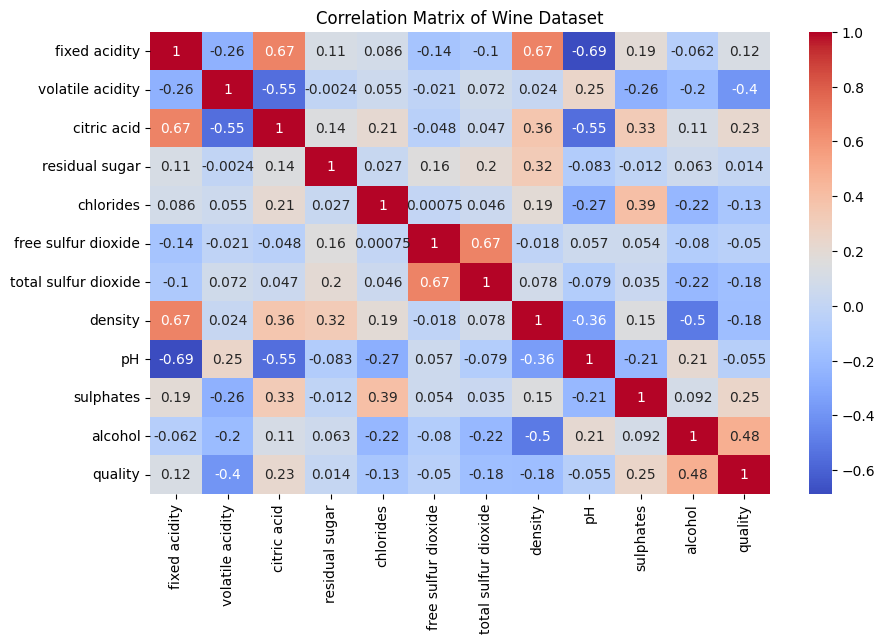

In [8]:
import seaborn as sns
#plot of correlation matrix to visualize the relation between features and the quality
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Wine Dataset")
plt.show()

**1) Fixed Acidity vs Quality (correlation is 0.1190):**

The correlation between fixed acidity and wine quality is weakly positive. This indicates that fixed acidity has only a small influence on wine quality.


**2)Alcohol vs Quality(correlation is 0.4803):**

Alcohol shows a moderate positive correlation with wine quality. This suggests that wines with higher alcohol content tend to receive higher quality ratings.


**3)Free Sulfur Dioxide vs Quality(correlation is -0.05):**

Free sulfur dioxide has a very weak negative correlation with wine quality, indicating that it has little influence on the quality score.

# **QUESTION 3**

###What is the average `residual sugar` for the best quality wine and the lowest quality wine in the dataset?

In [9]:
#best quality corresponding to the data having highest quality
best_quality=data['quality'].max()
#low quality corresponds to the data having low quality
low_quality=data['quality'].min()
print(f"best quality: {best_quality}")
print(f"low quality: {low_quality}")

avg_residual_best=data[data['quality']==best_quality]['residual sugar'].mean()
avg_residual_low=data[data['quality']==low_quality]['residual sugar'].mean()

print(f"average residual sugar for best quality: {avg_residual_best:.4f}")
print(f"average residual sugar for low quality: {avg_residual_low:.4f}")


best quality: 8
low quality: 3
average residual sugar for best quality: 2.5765
average residual sugar for low quality: 2.6350


The average residual sugar for the best quality wines is 2.5765, while for the lowest quality wines it is 2.6350. This suggests that residual sugar does not vary significantly between the highest and lowest quality wines in the dataset.

# **QUESTION 4**

###Does `volatile acidity` has an effect over the quality of the wine samples in the dataset?

In [10]:
#this function gives acording to correlation value(-1 to 1) how strong or weak the feature
def interpret_corr(value):
    if value > 0.5:
        return "strong positive correlation"
    elif value > 0.2:
        return "moderate positive correlation"
    elif value > 0:
        return "weak positive correlation"
    elif value < -0.5:
        return "strong negative correlation"
    elif value < -0.2:
        return "moderate negative correlation"
    elif value < 0:
        return "weak negative correlation"
    else:
        return "no correlation"

In [11]:
corr_volatile=data['volatile acidity'].corr(data['quality'])
print(f"correlation(volatile acidity vs quality)= {corr_volatile:.4f}")
print(f"Therfore, volatile acidity has {interpret_corr(corr_volatile)} with wine quality")

correlation(volatile acidity vs quality)= -0.3952
Therfore, volatile acidity has moderate negative correlation with wine quality


# **QUESTION 5**

###Train a Decision Tree model and Random Forest Model separately to predict the Quality of the given samples of wine. Compare the Accuracy scores for both models.

In [12]:
#X->represents the features data
#y-> represents the quality
X=data.drop(columns='quality',axis=1)
y=data['quality']
print(f"X :{X.shape}")
print(f"y: {y.shape}")
# splitting the data to train the model
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

X :(1359, 11)
y: (1359,)


In [13]:
#training the data with decision tree
model_dt=DecisionTreeClassifier()
model_dt.fit(X_train,y_train)
y_pred_dt=model_dt.predict(X_test)
acc_dt=accuracy_score(y_test,y_pred_dt)

#training the data with random forest
model_rf=RandomForestClassifier()
model_rf.fit(X_train,y_train)
y_pred_rf=model_rf.predict(X_test)
acc_rf=accuracy_score(y_test,y_pred_rf)

print(f"Decision Tree Accuracy: {acc_dt:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

#comparing the results
if acc_rf > acc_dt:
    print("Random Forest performs better than Decision Tree.")
elif acc_rf < acc_dt:
    print("Decision Tree performs better than Random Forest.")
else:
    print("Both models have the same accuracy.")

Decision Tree Accuracy: 0.5037
Random Forest Accuracy: 0.6507
Random Forest performs better than Decision Tree.


Both Decision Tree and Random Forest models were trained to predict wine quality using physicochemical properties. The Random Forest model achieved higher accuracy compared to the Decision Tree model. This is because Random Forest combines multiple decision trees and reduces overfitting, leading to improved prediction performance.